# Machine Learning-Based Classification of Normal and Abnormal Vertebral Conditions Using Biomechanical Features

**Dataset:**

Vertebral Column

**Group 17:**

* Aida Davoudian Beni
* Sara Ashna
* Ana Butkhuzi

# Introduction
## Biological Question

Spinal disorders such as disk hernia and spondylolisthesis are associated with changes in the biomechanical alignment and structural relationships of the lumbar spine and pelvis. These conditions as they affect spinal stability and posture, can be used for clinical assessment.

Spinal disorders are traditionally diagnosed using clinical examination and imaging techniques. Biomechanical measurements provide additional quantitative information about spinal alignment and mechanical properties.

In this project, we will apply machine learning methods to investigate whether quantitative biomechanical features of the vertebral column can be used to distinguish between normal individuals and patients with abnormal spinal conditions. The analysis is based on the Vertebral Column dataset obtained from the UCI Machine Learning Repository, which contains measurements collected from 310 patients.




# Loading The Assigned Data

For this project, we are using the Vertebral Column dataset from the UCI Machine Learning Repository, where machine learning datasets are publicly available.

The dataset was imported using  `fetch_ucirepo()` function from `ucimlrepo` package. The functin retrieves the data by specifying its unique dataset ID from the UCI repository.

In [14]:
!pip install ucimlrepo

import pandas as pd

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    raise ImportError("Install ucimlrepo first with: !pip install ucimlrepo")

# Dataset 7 - Vertebral Column
vertebral = fetch_ucirepo(id = 212)

# Dataset Description
After loading the dataset, to prepare the data for machine learning analysis, the data was divided into input features and the target variable. The features represent the biomechanical measurements used for classification and target variable contains diagnostic category.

For the classification task, the original three-class labels were transformed into a binary format:
- **0** = Normal vertebral condition
- **1** = Abnormal spinal condition (Hernia or Spondylolisthesis)

In [15]:
# Features
X = vertebral.data.features.copy()

# Original target
y_original = vertebral.data.targets.iloc[:, 0].copy()

print("Original target values:")
print(pd.Series(y_original).value_counts())

# Binary target
y_binary = pd.Series(y_original).astype(str).str.lower().apply(
    lambda value: 0 if "normal" in value else 1
)
y_binary.name = "abnormal_spine_condition"

# Combined Dataset
vertebral_data = pd.concat([X, y_binary], axis=1)

print("\nX shape:", X.shape)
print("Binary y shape:", y_binary.shape)
print("Binary target counts:")
print(y_binary.value_counts())


display(vertebral_data.head())

print("\nInfo:")
X.info()

print("\nSummary statistics:")
display(X.describe())

print("\nMissing values:")
print(X.isna().sum())


Original target values:
class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64

X shape: (310, 6)
Binary y shape: (310,)
Binary target counts:
abnormal_spine_condition
1    210
0    100
Name: count, dtype: int64


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,abnormal_spine_condition
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
dtypes: float64(6)
memory usage: 14.7 KB

Summary statistics:


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082



Missing values:
pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
dtype: int64


The dataset contains 310 patient samples with 6 biomechanical measurements used as predictive features.
After transforming the original target variable into two groups, the data contained normal cases of 100 patients and abnormal cases of 210 patients.

The dataset information shows that all six features are stored as continuous numerical variables and contain 310 valid observations each. No missing values were detected, so no additional step was required to apply before model training.

# Exploratory Data Analysis
After confirming the structure and quality of the dataset, exploratory data analysis (EDA) was performed to better understand the distribution of variables and the relationship between biomechanical measurements.



       pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
count        310.000000   310.000000             310.000000    310.000000   
mean          60.496653    17.542822              51.930930     42.953831   
std           17.236520    10.008330              18.554064     13.423102   
min           26.147921    -6.554948              14.000000     13.366931   
25%           46.430294    10.667069              37.000000     33.347122   
50%           58.691038    16.357689              49.562398     42.404912   
75%           72.877696    22.120395              63.000000     52.695888   
max          129.834041    49.431864             125.742385    121.429566   

       pelvic_radius  degree_spondylolisthesis  
count     310.000000                310.000000  
mean      117.920655                 26.296694  
std        13.317377                 37.559027  
min        70.082575                -11.058179  
25%       110.709196                  1.603727  
50%       11

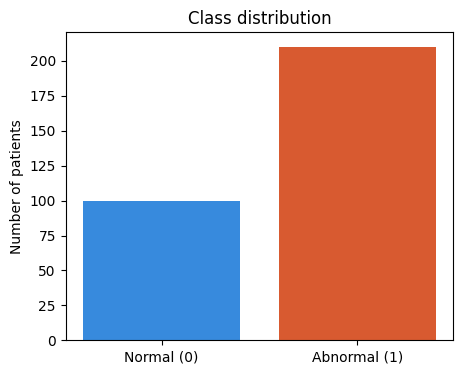

In [16]:
# Descriptive statistics
print(X.describe())

# Class balance
print(y_binary.value_counts(normalize=True))

# Visualization of class distribution
import matplotlib.pyplot as plt
import numpy as np
labels_bar = ["Normal (0)", "Abnormal (1)"]
counts = [np.sum(y_binary == 0), np.sum(y_binary == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels_bar, counts, color=["#378ADD", "#D85A30"])
plt.ylabel("Number of patients")
plt.title("Class distribution")
plt.show()

The statistics show that all biomechanical features contain 310 observations and have different ranges and levels of variability. Due to differences in feature scaling, standardization may be required before applying the ML algorithms.

The target distribution shows that the abnormal condition group represents a larger proportion of the dataset compared with the normal group. This moderate imbalance should be considered during model evaluation.

To further examine the variability of the biomechanical measurements, the distribution of each feature was visualized using histograms.

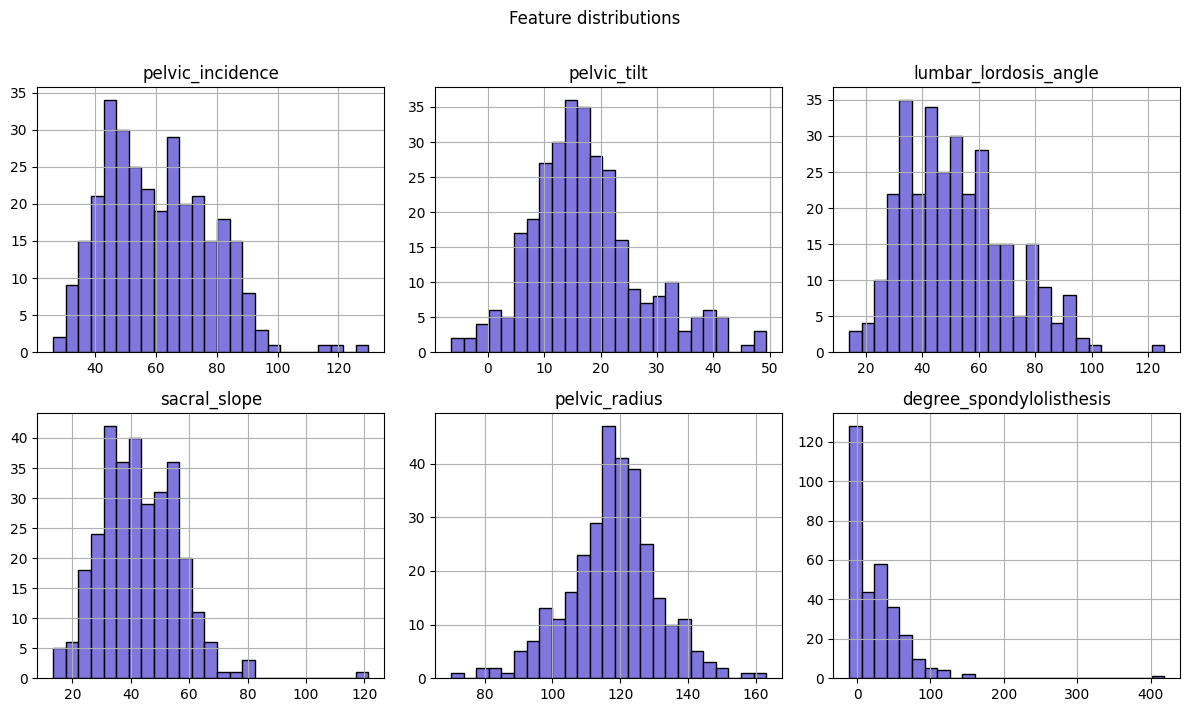

In [17]:
# Feature distributions (histograms)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flatten(), X.columns):
    X[col].hist(ax=ax, bins=25, edgecolor='black', color='#7F77DD')
    ax.set_title(col)
plt.suptitle("Feature distributions", y=1.01)
plt.tight_layout()
plt.show()

The feature distributions show that the biomechanical measurements have different patterns and ranges across the dataset. Some variables display a wider spread of values, while others show a more concentrated distribution.

To investigate relationships between these features, a correlation analysis was performed.

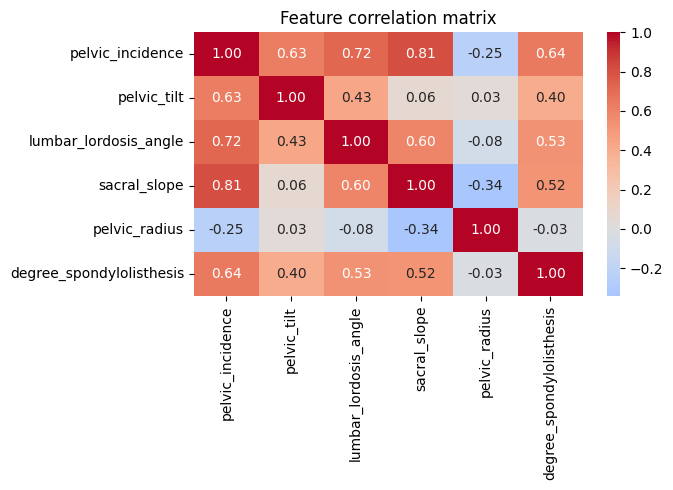

Pelvic incidence = tilt + slope residual (should be ~0): count    3.100000e+02
mean     1.258069e-10
std      4.673167e-09
min     -1.000001e-08
25%     -7.105427e-15
50%      0.000000e+00
75%      7.105427e-15
max      1.000001e-08
dtype: float64


In [18]:
import seaborn as sns

# Correlation heatmap
corr = X.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

# Check geometric identity
residual = X["pelvic_incidence"] - X["pelvic_tilt"] - X["sacral_slope"]
print("Pelvic incidence = tilt + slope residual (should be ~0):", residual.describe())

Correlation analysis revealed strong positive relationships among pelvic incidence, sacral slope, and lumbar lordosis angle, which is expected because measurements describe related anatomical aspects of spinal and pelvic parameters. These correlations suggest the possibility of multicollinearity, where some features may provide overlapping information.




# Machine Learning Task
Based on the exploratory analysis, the machine learning problem was defined as a binary classification task. The objective is to classify patients into two categories: normal vertebral condition and abnormal spinal condition using biomechanical measurements of the vertebral column.

The dataset contains 310 patient samples with six quantitative biomechanical features. As the dataset size is relatively small (to reduce the risk of overfitting), **logistic regression** was chosen as a baseline model and **decision tree** - as an alternative non-linear model.



# Data preprocessing
Before training the classification models, the dataset was divided into training and testing subsets. The training set will be used for model development, while the test set will be kept separate for evaluating the final model performance on unseen data.

Because the dataset contains a relatively small number of samples, cross-validation will be applied during model evaluation to obtain a more reliable estimate of model performance.

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Baseline Model: Logistic Regression



In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# Logistic Regression pipeline
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

# 5-fold stratified cross-validation on training data
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation evaluation
cv_results = cross_validate(
    log_reg,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

# Mean CV results
print("Accuracy :", cv_results["test_accuracy"].mean())
print("Precision:", cv_results["test_precision"].mean())
print("Recall   :", cv_results["test_recall"].mean())
print("F1-score :", cv_results["test_f1"].mean())

Accuracy : 0.8023673469387754
Precision: 0.9198891625615764
Recall   : 0.7800356506238859
F1-score : 0.8429990011163992


# Alternative Model: Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Decision Tree model
tree_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation evaluation
tree_results = cross_validate(
    tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=False
)

# Mean CV results
print("Decision Tree CV Results")
print("------------------------")
print("Accuracy :", tree_results["test_accuracy"].mean())
print("Precision:", tree_results["test_precision"].mean())
print("Recall   :", tree_results["test_recall"].mean())
print("F1-score :", tree_results["test_f1"].mean())

Decision Tree CV Results
------------------------
Accuracy : 0.7779591836734695
Precision: 0.8218538634966182
Recall   : 0.8625668449197861
F1-score : 0.8405020657092269


# Model Comparison
After training and evaluating the machine learning models (using cross-validation), their performances were compared based on evaluation metrics: accuracy, precision, recall and F1-score.

In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        cv_results["test_accuracy"].mean(),
        tree_results["test_accuracy"].mean()
    ],
    "Precision": [
        cv_results["test_precision"].mean(),
        tree_results["test_precision"].mean()
    ],
    "Recall": [
        cv_results["test_recall"].mean(),
        tree_results["test_recall"].mean()
    ],
    "F1-score": [
        cv_results["test_f1"].mean(),
        tree_results["test_f1"].mean()
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.802367,0.919889,0.780036,0.842999
1,Decision Tree,0.777959,0.821854,0.862567,0.840502


The comparison shows that Logistic Regression achieved slightly higher overall performance compared with Decision Tree, with higher accuracy and F1-score. Logistic Regression also demonstrated higher precision, indicating a lower proportion of false positive predictions.

Decision Tree achieved a slightly higher recall, meaning it was better at identifying abnormal cases, but its overall performance was lower compared with Logistic Regression. Considering the balance between identifying abnormal conditions and maintaining reliable predictions, Logistic Regression was selected as the preferred model for final evaluation.


# Final Model Selection
Based on cross-validation results, logistic regression was selected as the final model. The model was retrained using the complete training dataset before evaluating its performance on the unseen test data.

In [23]:
# Select best model
best_model = log_reg

# Train on the full training data
best_model.fit(X_train, y_train)

# Predict on unseen test data
y_test_pred = best_model.predict(X_test)

# Get probabilities
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# Final Test Evaluation
After fitting the selected model on the complete training dataset, predictions were generated for the test dataset, which remained completely unseen during model development and validation. To evaluate the model’s ability to generalize to new data, the same performance metrics used during validation were applied to the 62 held-out test samples. The final evaluation included accuracy, F1-score, ROC-AUC, a detailed classification report, a confusion matrix, and a ROC curve, providing a comprehensive assessment of the model’s predictive performance on unseen observations.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Final Logistic Regression Test Performance")
print("------------------------------------------")

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Final Logistic Regression Test Performance
------------------------------------------
Accuracy : 0.8870967741935484
Precision: 0.972972972972973
Recall   : 0.8571428571428571
F1-score : 0.9113924050632911

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.95      0.84        20
           1       0.97      0.86      0.91        42

    accuracy                           0.89        62
   macro avg       0.87      0.90      0.88        62
weighted avg       0.90      0.89      0.89        62



Based on the evaluation metrics, we can say that the model achieved good overall performance, demonstrating that biomechanical features can be used to distinguish between normal and abnormal vertebral conditions.

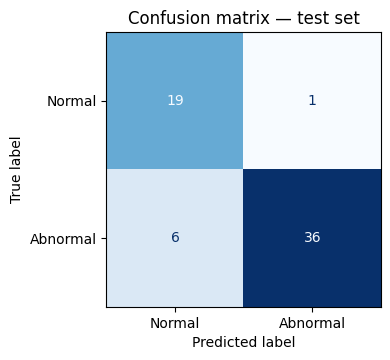

True Negatives  (Normal correctly classified)   : 19
False Positives (Normal misclassified as Abnormal): 1
False Negatives (Abnormal missed by model)      : 6
True Positives  (Abnormal correctly classified) : 36


In [27]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Confusion matrix
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Normal", "Abnormal"],
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

# Interpretation
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Normal correctly classified)   : {tn}")
print(f"False Positives (Normal misclassified as Abnormal): {fp}")
print(f"False Negatives (Abnormal missed by model)      : {fn}")
print(f"True Positives  (Abnormal correctly classified) : {tp}")

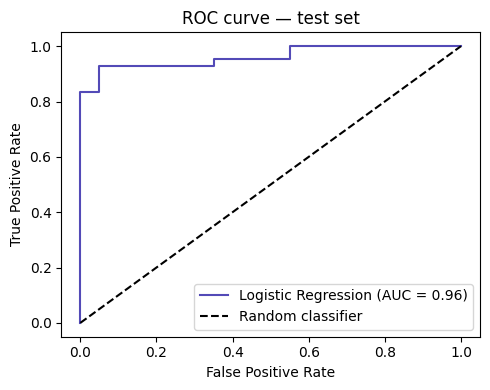

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_val = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="#534AB7", label=f"Logistic Regression (AUC = {auc_val:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — test set")
plt.legend()
plt.tight_layout()
plt.show()